In [19]:
import os
import sys
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# Ensure src/ is importable
sys.path.append(os.path.abspath('../src'))

from data_loader import load_demographics
from models import GNNPredictor
from torch_geometric.nn import knn_graph
from torch_geometric.utils import to_undirected, scatter
from torch_geometric import seed_everything

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [20]:
# Parameters
urbe = 'Philadelphia'
dem_var_name = 'Median_Income'
macroentity = 'zip'  # 'zip' or 'tract'
n_quantiles = 2

# Choose the embedding/model family to load (must match saved files in ../results/yelp2019/)
model_embs = 'LightGCN'  # alternatives: 'LightGCN', 'FeatLightGCN', 'FeatAndPCLightGCN', 'NoEdges', 'NoFeatures', 'NoPreTrain'

business_csv_path = '../datasets/yelp2019_business.csv'
models_dir = '../results/yelp2019/'
pa_bg_path = '../datasets/PA_bg.zip'  # block groups for Pennsylvania
pa_tracts_path = '../datasets/PA_tracts.zip'  # tracts for Pennsylvania
pa_zips_path = '../datasets/PA_zip_codes_geo.min.json'  # zip codes for Pennsylvania

In [21]:
# Helper to create spatial kNN graph and aggregate labels as in training script
def create_spatial_graph(state_buss, buss_out_embs, macroentity, k=10, device='cpu'):
    latitudes = torch.tensor(state_buss.latitude.values, dtype=torch.float).view(-1, 1)
    longitudes = torch.tensor(state_buss.longitude.values, dtype=torch.float).view(-1, 1)
    # convert degrees to radians
    latitudes = latitudes * (np.pi / 180)
    longitudes = longitudes * (np.pi / 180)

    # convert to x, y and z coordinates
    x = torch.cos(latitudes) * torch.cos(longitudes)
    y = torch.cos(latitudes) * torch.sin(longitudes)
    z = torch.sin(latitudes)
    pos = torch.cat([x, y, z], dim=1)

    edge_index = knn_graph(pos, k=k, loop=False)
    edge_index = to_undirected(edge_index)

    train_y = torch.tensor(state_buss.train_target.values.astype(int), dtype=torch.long).view(-1)
    test_y = torch.tensor(state_buss.test_target.values.astype(int), dtype=torch.long).view(-1)

    block_groups = state_buss.block_group_id.values
    macroentities = state_buss[f'{macroentity}_id'].values

    # mapped np.array from block group id to integer
    _, block_groups = np.unique(block_groups, return_inverse=True)
    _, macroentities = np.unique(macroentities, return_inverse=True)
    block_group_ids = torch.tensor(block_groups, dtype=torch.long).view(-1)
    macroentity_ids = torch.tensor(macroentities, dtype=torch.long).view(-1)

    # create a mapping from the block group id to its macroentity id
    blockgroup_to_macroentity = {}
    for bg_id, me_id in zip(block_group_ids.numpy(), macroentity_ids.numpy()):
        blockgroup_to_macroentity[bg_id] = me_id
    blockgroup_to_macroentity = dict(sorted(blockgroup_to_macroentity.items()))
    #blockgroup_to_macroentity_tensor = torch.tensor(list(blockgroup_to_macroentity.values()), dtype=torch.long)

    train_labels = scatter(train_y, macroentity_ids, dim=0, reduce='mean').long()
    test_labels = scatter(test_y, block_group_ids, dim=0, reduce='mean').long()
    train_to_test_labels = scatter(train_y, block_group_ids, dim=0, reduce='mean').long()

    from torch_geometric.data import Data
    data = Data(
        x=buss_out_embs,
        edge_index=edge_index,
        train_y=train_labels,
        test_y=test_labels,
        train_to_test_y=train_to_test_labels,
        me_subgraph=macroentity_ids,
        bg_subgraph=block_group_ids
    ).to(device)
    return data

In [22]:
# Load business data and full demographics (cached to ../datasets/yelp2019_demographics.csv)
business_df = pd.read_csv(business_csv_path)

# Clean types as in training
business_df.loc[:, 'postal_code'] = business_df['postal_code'].fillna(0)
business_df['postal_code'] = business_df['postal_code'].astype(str)
business_df.loc[:, 'block_group_id'] = business_df['block_group_id'].fillna(0)
business_df['block_group_id'] = business_df['block_group_id'].astype(int).astype(str)

block_groups = business_df['block_group_id'].unique()

# State name to abbreviation mapping used for super-res
states_names_for_superres = {
    'Illinois': 'IL',
    'New Jersey': 'NJ',
    'Delaware': 'DE',
    'Missouri': 'MO',
    'Pennsylvania': 'PA',
    'Tennessee': 'TN',
    'Florida': 'FL',
    'Indiana': 'IN',
}

full_bg_df = load_demographics(states_names_for_superres, block_groups)
# Keep only macroentities having more than one BG
full_bg_df = full_bg_df.groupby(macroentity).filter(lambda x: len(x) > 1)

Block groups demographics already downloaded


In [23]:
# Filter to the target urban area and build targets
curr_buss = business_df.urban_area == urbe
curr_buss_df = business_df.loc[curr_buss].copy()
curr_bg = curr_buss_df.block_group_id.unique()
# Keep only BGs present in demographics
curr_bg = [bg for bg in curr_bg if bg in full_bg_df.index]
curr_buss = business_df.block_group_id.isin(curr_bg)
curr_buss_df = business_df.loc[curr_buss].copy()

# Drop businesses whose BG or macroentity target is null
curr_buss_df = curr_buss_df[~curr_buss_df.block_group_id.isin(full_bg_df[full_bg_df[dem_var_name].isnull()].index)]
curr_buss_df = curr_buss_df[~curr_buss_df.block_group_id.isin(full_bg_df[full_bg_df[f'{dem_var_name}_{macroentity}'].isnull()].index)]

# Attach macroentity id from demographics
curr_buss_bg = curr_buss_df.block_group_id.values
curr_buss_df[f'{macroentity}_id'] = full_bg_df.loc[curr_buss_bg, f'{macroentity}_dcid'].values

# Prepare binned targets as in training
curr_bg_values = full_bg_df.loc[curr_bg, dem_var_name].values
if len(curr_bg_values) == 0:
    raise RuntimeError('No BG values found for selection; check inputs.')
curr_me_values = full_bg_df.loc[curr_bg, f'{dem_var_name}_{macroentity}'].values
valid_bg = ~np.isnan(curr_me_values) & ~np.isnan(curr_bg_values)
curr_bg = np.array(curr_bg)[valid_bg]
curr_me_values = curr_me_values[valid_bg]
curr_bg_values = curr_bg_values[valid_bg]

full_bg_df.loc[curr_bg, f'binned_{dem_var_name}_{macroentity}'] = pd.qcut(curr_me_values, q=n_quantiles, labels=False, duplicates='drop')
full_bg_df.loc[curr_bg, f'binned_{dem_var_name}'] = pd.qcut(curr_bg_values, q=n_quantiles, labels=False, duplicates='drop')
full_bg_df.loc[curr_bg, f'ranking_{dem_var_name}_{macroentity}'] = pd.Series(curr_me_values).rank().values / len(curr_me_values)

# Assemble the per-business frame needed by the graph builder
curr_buss_df = curr_buss_df[['block_group_id', f'{macroentity}_id', 'longitude', 'latitude', 'state']].copy()
curr_buss_df.loc[:, 'train_target'] = full_bg_df.loc[curr_buss_bg, f'binned_{dem_var_name}_{macroentity}'].values
curr_buss_df.loc[:, 'test_target'] = full_bg_df.loc[curr_buss_bg, f'binned_{dem_var_name}'].values
curr_buss_df.loc[:, 'ranking_train'] = full_bg_df.loc[curr_buss_bg, f'ranking_{dem_var_name}_{macroentity}'].values

curr_buss_df = curr_buss_df.dropna().copy()
print(f'Businesses kept for {urbe}:', len(curr_buss_df))

Businesses kept for Philadelphia: 14992


In [24]:
# Load business embeddings and build the graph
if model_embs == 'NoPreTrain':
    bus__out_embeddings = torch.arange(len(curr_buss_df), dtype=torch.long).view(-1)
else:
    bus__out_embeddings = np.load(f'{models_dir}{model_embs}__bus__out_embeddings.npy')
    bus__out_embeddings = torch.tensor(bus__out_embeddings[curr_buss_df.index], dtype=torch.float)


graph_data = create_spatial_graph(curr_buss_df, bus__out_embeddings, macroentity, k=10, device=device)
graph_data

Data(x=[14992, 64], edge_index=[2, 189966], train_y=[189], test_y=[1472], train_to_test_y=[1472], me_subgraph=[14992], bg_subgraph=[14992])

In [25]:
# Load trained checkpoint and run inference at BG level
checkpoint = os.path.join(models_dir, f"super_res_classification__{model_embs}__{urbe}__{dem_var_name}__{macroentity}__nquantiles{n_quantiles}__model.pth")
assert os.path.exists(checkpoint), f'Checkpoint not found: {checkpoint}'

if model_embs == 'NoPreTrain':
    model = GNNPredictor(in_channels=32, hidden_channels=32, num_classes=n_quantiles, learnable_emb=True, num_nodes=len(curr_buss_df)).to(device)
else:
    model = GNNPredictor(in_channels=graph_data.num_features, hidden_channels=32, num_classes=n_quantiles).to(device)

state = torch.load(checkpoint, map_location=device)
model.load_state_dict(state)
model.eval()

with torch.no_grad():
    logits_bg = model(graph_data.x, graph_data.edge_index, graph_data.bg_subgraph)  # BG-level pooling
    probs_bg = torch.softmax(logits_bg, dim=1).cpu().numpy()
    pred_bg = probs_bg.argmax(axis=1)

# Map BG index -> original BG code (np.unique sorts, consistent with create_spatial_graph mapping)
unique_bg_codes = np.unique(curr_buss_df.block_group_id.values)
pred_df = pd.DataFrame({'block_group_id': unique_bg_codes, 'pred_class': pred_bg, 'pred_prob': probs_bg[:, 1], 'true_class': graph_data.test_y.cpu().numpy()})
pred_df.head()

# now the same but at tract level
with torch.no_grad():
    logits_me = model(graph_data.x, graph_data.edge_index, graph_data.me_subgraph)  # macroentity-level pooling
    probs_me = torch.softmax(logits_me, dim=1).cpu().numpy()
    pred_me = probs_me.argmax(axis=1)


# finally the same but at business level
with torch.no_grad():
    logits_buss = model(graph_data.x, graph_data.edge_index)  # business-level predictions
    probs_buss = torch.softmax(logits_buss, dim=1).cpu().numpy()
    pred_buss = probs_buss.argmax(axis=1)

# add preds to curr_buss_df
curr_buss_df['pred_prob'] = probs_buss[:, 1]
curr_buss_df['pred_class'] = pred_buss

unique_me_codes = np.unique(curr_buss_df[f'{macroentity}_id'].values)
# remove in unique_me_codes all text before the slash
unique_me_codes = [code.split('/')[1] for code in unique_me_codes]
pred_me_df = pd.DataFrame({'macroentity_id': unique_me_codes, 'pred_class': pred_me, 'pred_prob': probs_me[:, 1], 'true_class': graph_data.train_y.cpu().numpy()})
pred_me_df.head()

,macroentity_id,pred_class,pred_prob,true_class
0,08003,1,0.882323,1
1,08007,1,0.884681,1
2,08009,1,0.865321,1
3,08010,1,0.750966,0
4,08012,1,0.819825,1


In [26]:
# Load PA block groups and merge predictions
blocks_shapes = gpd.read_file(pa_bg_path)[['GEOID', 'geometry']].rename(columns={'GEOID': 'block_group_id'})
blocks_shapes['block_group_id'] = blocks_shapes['block_group_id'].astype(str)
merged = blocks_shapes.merge(pred_df, on='block_group_id', how='left')
plot_gdf = merged.copy()
# turn NaN predictions into a separate class if needed
plot_gdf['pred_class'] = plot_gdf['pred_class'].fillna(-1)
plot_gdf['pred_class'] = plot_gdf['pred_class'].astype(int)

plot_gdf['correct'] = (plot_gdf['pred_class'] == plot_gdf['true_class']).astype(int)
plot_gdf.head()

,block_group_id,geometry,pred_class,pred_prob,true_class,correct
0,420950176071,"POLYGON ((-75.31069 40.65447, -75.31062 40.654...",-1,NaN,NaN,0
1,420950167002,"POLYGON ((-75.34699 40.74173, -75.34698 40.742...",-1,NaN,NaN,0
2,420950167003,"POLYGON ((-75.30571 40.7468, -75.30563 40.7468...",-1,NaN,NaN,0
3,420750033002,"POLYGON ((-76.39726 40.34284, -76.3967 40.3430...",-1,NaN,NaN,0
4,420750033003,"POLYGON ((-76.39028 40.3455, -76.39017 40.3455...",-1,NaN,NaN,0


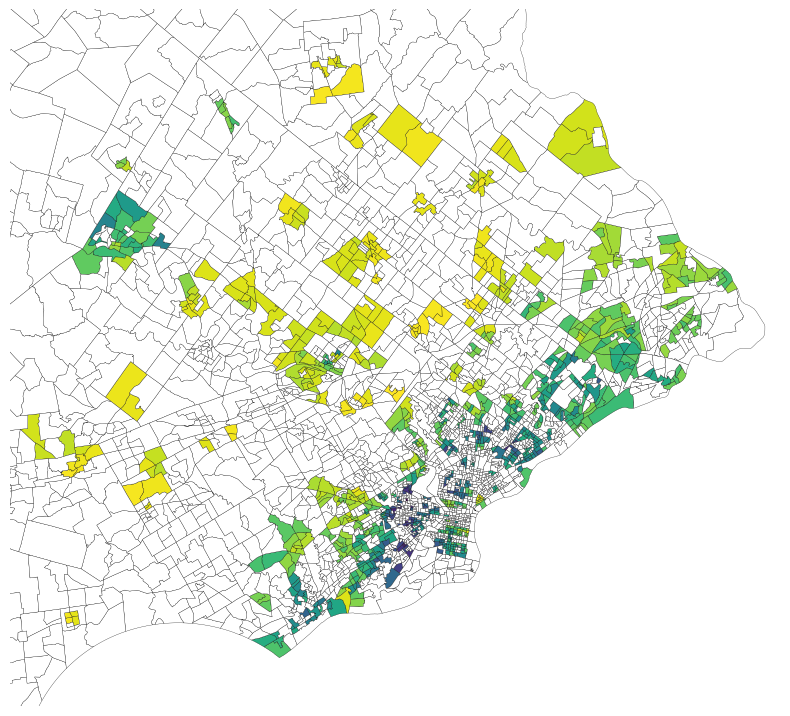

In [27]:
# Plot BG predictions over the Philadelphia area
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
plot_gdf.plot(column='pred_prob', ax=ax, cmap='viridis', linewidth=0.2, edgecolor='black', legend=False)
ax.set_axis_off()

# plot the BGs with pred_class == -1 (no prediction) as grey
no_pred_gdf = plot_gdf[plot_gdf['pred_class'] == -1]
no_pred_gdf.plot(ax=ax, color='white', linewidth=0.2, edgecolor='black')
# plot the business locations
# business_points = [Point(xy) for xy in zip(curr_buss_df.longitude, curr_buss_df.latitude)]
# business_gdf = gpd.GeoDataFrame(curr_buss_df, geometry=business_points, crs='EPSG:4326')
# #business_gdf.plot(ax=ax, color='black', markersize=5, alpha=0.7, label='Businesses')
# remove colorbar


# Focus around Philadelphia bounds
ax.set_xlim([-75.8, -74.7])
ax.set_ylim([39.75, 40.5])
fig.tight_layout()

fig.savefig('../results/figures/example_philly_bg_pred_probs_median_income.pdf')



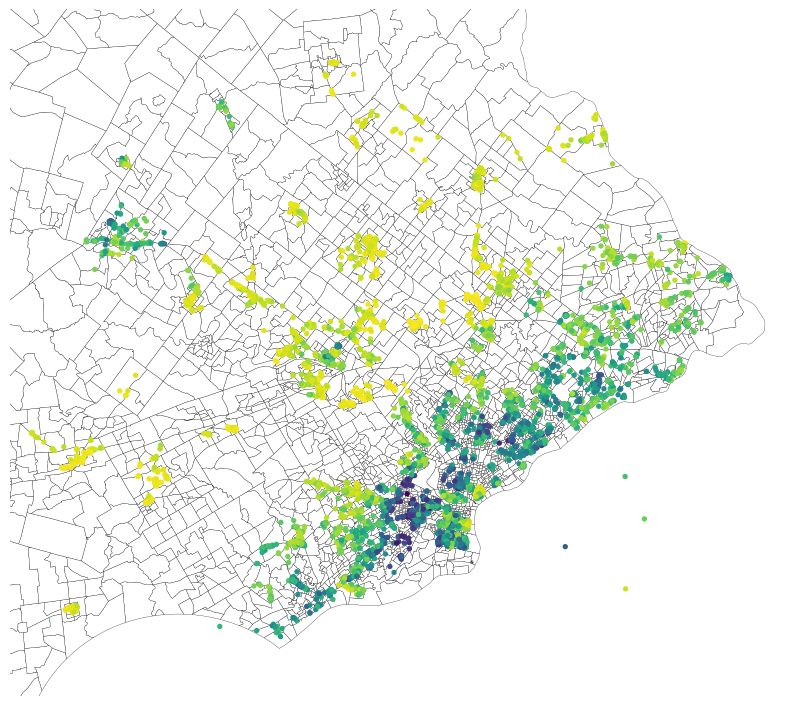

In [28]:
# Plot BG predictions over the Philadelphia area
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
plot_gdf.plot(ax=ax, linewidth=0.2, edgecolor='black',color='white')
ax.set_axis_off()
# plot the business locations
business_points = [Point(xy) for xy in zip(curr_buss_df.longitude, curr_buss_df.latitude)]
business_gdf = gpd.GeoDataFrame(curr_buss_df, geometry=business_points, crs='EPSG:4326')
business_gdf = business_gdf.loc[business_gdf['state'] == 'PA']
business_gdf.plot(ax=ax, column='pred_prob', cmap='viridis', markersize=8, alpha=1.0, label='Businesses')

# Focus around Philadelphia bounds
ax.set_xlim([-75.8, -74.7])
ax.set_ylim([39.75, 40.5])
fig.tight_layout()

fig.savefig('../results/figures/example_philly_business_pred_probs_median_income.pdf')



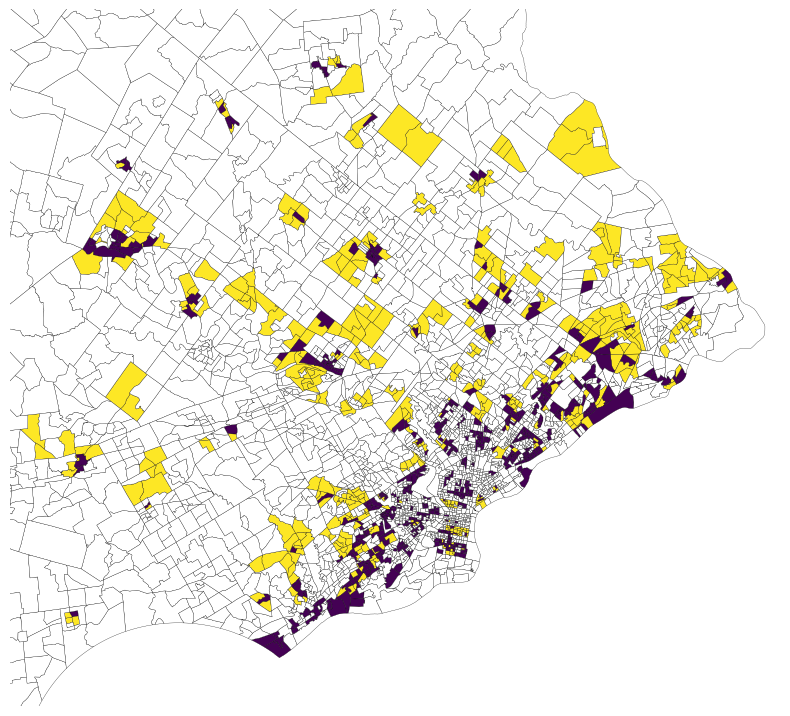

In [29]:
fig, ax = plt.subplots(figsize=(8, 8))
# Plot BG predictions over the Philadelphia area
plot_gdf.plot(column='true_class', ax=ax, cmap='viridis', linewidth=0.2, edgecolor='black', legend=False)
ax.set_axis_off()

# plot the BGs with pred_class == -1 (no prediction) as grey
no_pred_gdf = plot_gdf[plot_gdf['pred_class'] == -1]
no_pred_gdf.plot(ax=ax, color='white', linewidth=0.2, edgecolor='black')
# plot the business locations
# business_points = [Point(xy) for xy in zip(curr_buss_df.longitude, curr_buss_df.latitude)]
# business_gdf = gpd.GeoDataFrame(curr_buss_df, geometry=business_points, crs='EPSG:4326')
# #business_gdf.plot(ax=ax, color='black', markersize=5, alpha=0.7, label='Businesses')


# Focus around Philadelphia bounds
ax.set_xlim([-75.8, -74.7])
ax.set_ylim([39.75, 40.5])
fig.tight_layout()
fig.savefig('../results/figures/example_philly_bg_true_classes_median_income.pdf')

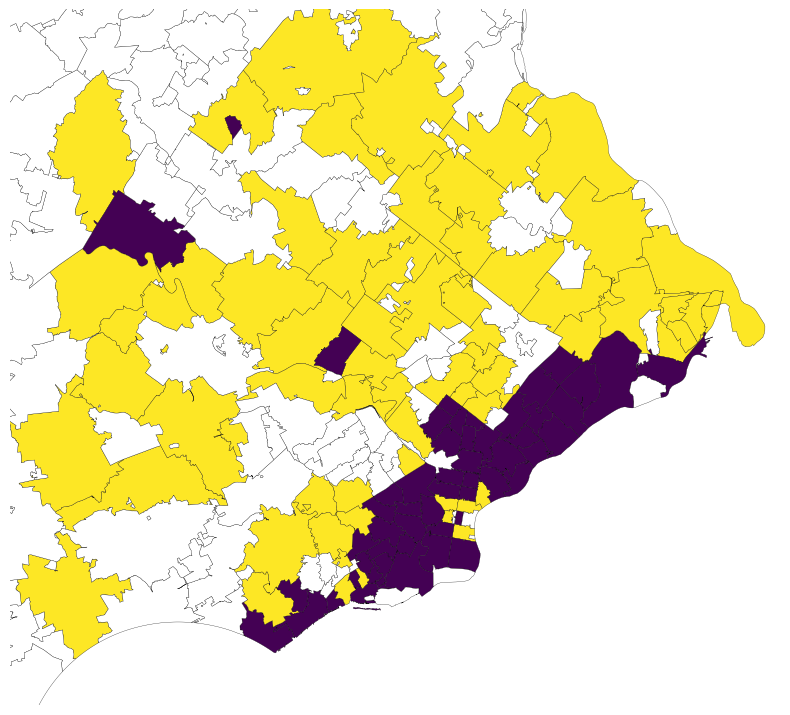

In [30]:
zip_shapes = gpd.read_file(pa_zips_path)[['ZCTA5CE10', 'geometry']].rename(columns={'ZCTA5CE10': 'zip_id'})
zip_shapes['zip_id'] = zip_shapes['zip_id'].astype(str)
plot_zips = zip_shapes.merge(pred_me_df, left_on='zip_id', right_on='macroentity_id', how='left')

plot_zips['pred_class'] = plot_zips['pred_class'].fillna(-1)
plot_zips['pred_class'] = plot_zips['pred_class'].astype(int)

fig, ax = plt.subplots(figsize=(8, 8))
# plot tract true_class
plot_zips.plot(column='true_class', ax=ax, cmap='viridis', linewidth=0.2, edgecolor='black', legend=False)
#ax.set_title('Train labels')
ax.set_axis_off()
# plot the tracts with pred_class == -1 (no prediction) as grey
no_pred_gdf = plot_zips[plot_zips['pred_class'] == -1]
no_pred_gdf.plot(ax=ax, color='white', linewidth=0.2, edgecolor='black')

# Focus around Philadelphia bounds
ax.set_xlim([-75.8, -74.7])
ax.set_ylim([39.75, 40.5])

fig.tight_layout()
fig.savefig('../results/figures/example_philly_zcta_train_labels_median_income.pdf')
plt.show()


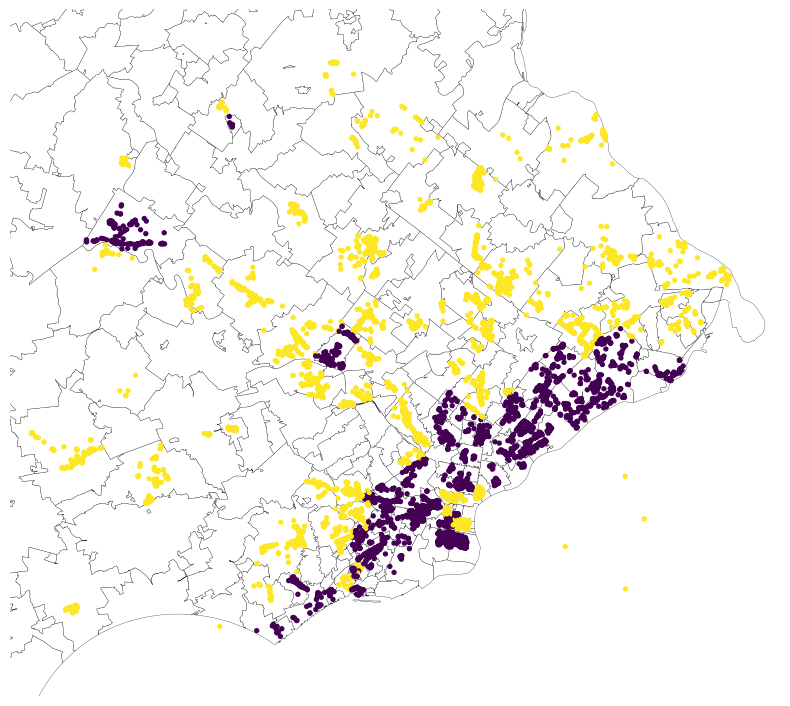

In [31]:

fig, ax = plt.subplots(figsize=(8, 8))
# plot tract true_class
plot_zips.plot(ax=ax, linewidth=0.2, edgecolor='black', color='white')
#ax.set_title('Train labels')
ax.set_axis_off()

business_points = [Point(xy) for xy in zip(curr_buss_df.longitude, curr_buss_df.latitude)]
business_gdf = gpd.GeoDataFrame(curr_buss_df, geometry=business_points, crs='EPSG:4326')
business_gdf = business_gdf.loc[business_gdf['state'] == 'PA']
business_gdf.plot(ax=ax, column='train_target', cmap='viridis', markersize=8, alpha=1.0, label='Businesses')


# Focus around Philadelphia bounds
ax.set_xlim([-75.8, -74.7])
ax.set_ylim([39.75, 40.5])

fig.tight_layout()
fig.savefig('../results/figures/example_philly_business_train_labels_median_income.pdf')


In [ ]:
tracts_shapes = gpd.read_file('../datasets/PA_tracts.zip')[['GEOID20', 'geometry']].rename(columns={'GEOID20': 'macroentity_id'})
tracts_shapes['macroentity_id'] = tracts_shapes['macroentity_id'].astype(str)
tracts_plot_gdf = tracts_shapes.merge(pred_me_df, on='macroentity_id', how='left')
# turn NaN predictions into a separate class if needed
tracts_plot_gdf['pred_class'] = tracts_plot_gdf['pred_class'].fillna(-1)
tracts_plot_gdf['pred_class'] = tracts_plot_gdf['pred_class'].astype(int)

fig, ax = plt.subplots(figsize=(8, 8))
# plot tract true_class
tracts_plot_gdf.plot(column='true_class', ax=ax, cmap='viridis', linewidth=0.2, edgecolor='black', legend=False)
ax.set_title('Train labels')
ax.set_axis_off()
# plot the tracts with pred_class == -1 (no prediction) as grey
no_pred_gdf = tracts_plot_gdf[tracts_plot_gdf['pred_class'] == -1]
no_pred_gdf.plot(ax=ax, color='white', linewidth=0.2, edgecolor='black')

# Focus around Philadelphia bounds
ax.set_xlim([-75.8, -74.7])
ax.set_ylim([39.75, 40.5])
plt.show()

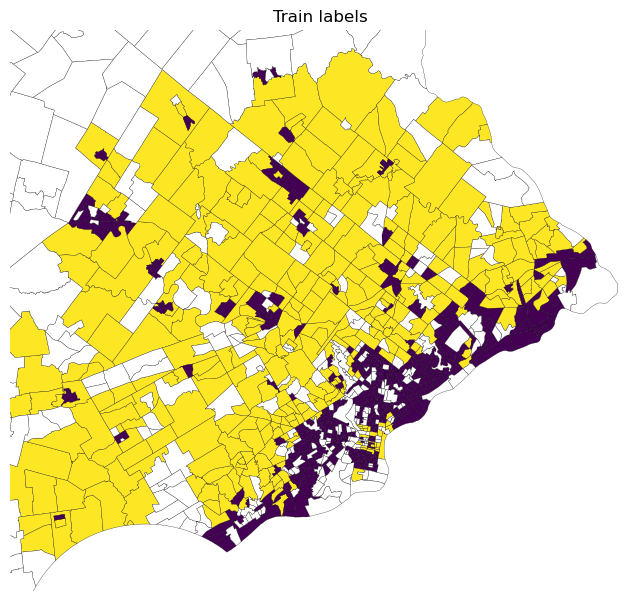